# Cross-Modal Semantic Vector Space Demo

This notebook demonstrates the core value proposition of the Semantic-Vector Space architecture:

**Image → Semantic Vector → Text**

By encoding different modalities into a shared semantic space, we enable cross-modal understanding without direct modality-to-modality translation. This eliminates semantic drift and creates a unified representation for multimodal data.

## Setup and Imports

In [1]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Add src to path for imports
sys.path.insert(0, str(Path.cwd() / "src"))

from Encoders.img_2_vec import Image_to_Vec
from Decoders.vec_2_text import Vec_to_Text

# Check device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


## Load Encoders and Decoders

We'll load:
- **Image_to_Vec**: Encodes images to 1024-dimensional semantic vectors
- **Vec_to_Text**: Decodes semantic vectors to natural language text

In [2]:
print("Loading Image Encoder...")
image_encoder = Image_to_Vec()
image_encoder.eval()  # Set to evaluation mode

print("Loading Text Decoder...")
text_decoder = Vec_to_Text()
text_decoder.eval()  # Set to evaluation mode

print("\n✓ Models loaded successfully!")

Loading Image Encoder...
Loading Text Decoder...
[Vec_to_Text] Decoder initialized with facebook/bart-base

✓ Models loaded successfully!


## Load Sample Image

For this demo, you can either:
1. Use your own image by setting `image_path` to a local file
2. Download a sample image from the internet

Modify the cell below to load your preferred image.

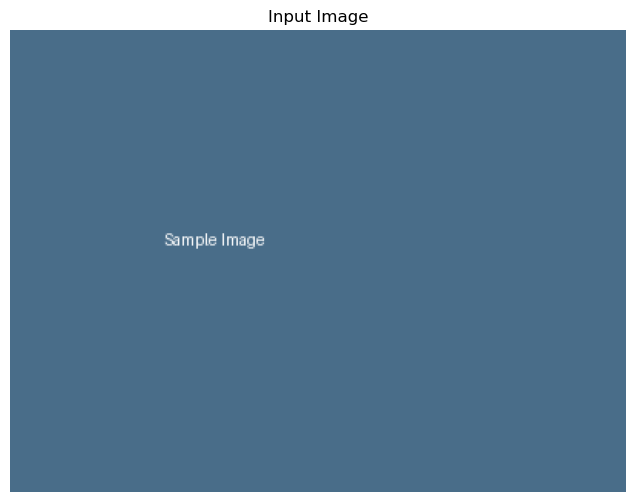

Image size: (400, 300)


In [3]:
# Option 1: Load local image
# image_path = "path/to/your/image.jpg"
# image = Image.open(image_path).convert("RGB")

# Option 2: Create a sample image for testing
# (Replace this with a real image for better results)
from PIL import Image, ImageDraw, ImageFont

# Create a simple test image
image = Image.new('RGB', (400, 300), color=(73, 109, 137))
draw = ImageDraw.Draw(image)
draw.text((100, 130), "Sample Image", fill=(255, 255, 255))

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.title("Input Image")
plt.show()

print(f"Image size: {image.size}")

## Step 1: Image → Semantic Vector

We encode the image into a 1024-dimensional semantic vector using the **Image_to_Vec** encoder.

**Architecture**: 
```
Image → ViT-GPT2 Encoder (frozen) → MLP Adapter (trained) → Semantic Vector
```

The adapter has been trained to align image features to the shared semantic space.

In [4]:
with torch.no_grad():
    semantic_vector = image_encoder(image, device=DEVICE)

print(f"Semantic Vector Shape: {semantic_vector.shape}")
print(f"Semantic Vector Statistics:")
print(f"  Mean: {semantic_vector.mean().item():.4f}")
print(f"  Std:  {semantic_vector.std().item():.4f}")
print(f"  Min:  {semantic_vector.min().item():.4f}")
print(f"  Max:  {semantic_vector.max().item():.4f}")

Semantic Vector Shape: torch.Size([1, 1024])
Semantic Vector Statistics:
  Mean: 0.0027
  Std:  0.0458
  Min:  -0.1314
  Max:  0.1103


### Visualize the Semantic Vector

Let's visualize the 1024-dimensional semantic vector to understand its distribution.

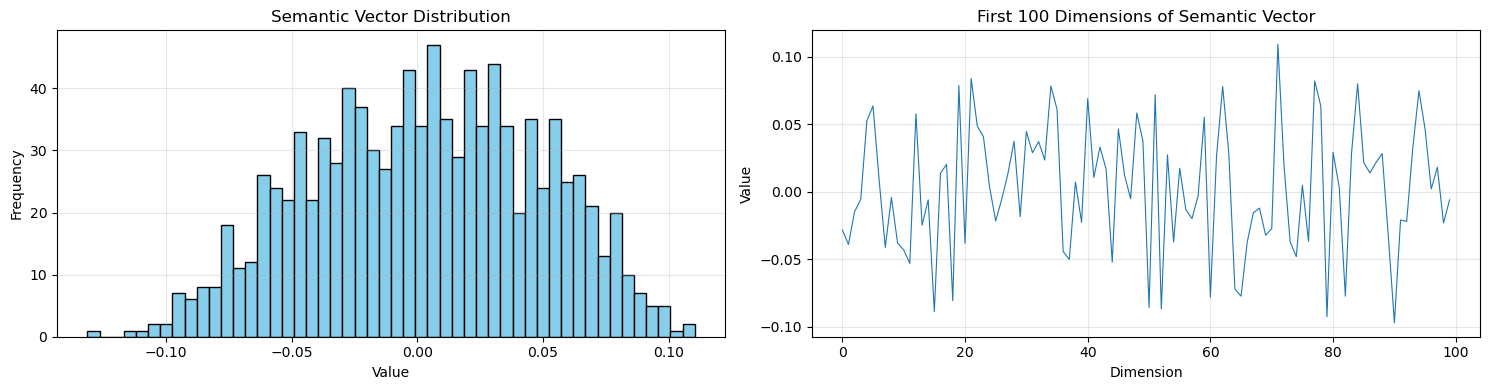

In [5]:
# Convert to numpy for visualization
vector_np = semantic_vector.cpu().numpy().flatten()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Histogram
axes[0].hist(vector_np, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Semantic Vector Distribution')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# Line plot of first 100 dimensions
axes[1].plot(vector_np[:100], linewidth=0.8)
axes[1].set_title('First 100 Dimensions of Semantic Vector')
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Value')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 2: Semantic Vector → Text

We decode the semantic vector into natural language text using the **Vec_to_Text** decoder.

**Architecture**:
```
Semantic Vector → MLP Adapter (trained) → BART Decoder → Text
```

The adapter translates from the semantic space to BART's latent space, then BART generates human-readable text.

In [6]:
with torch.no_grad():
    generated_text = text_decoder(semantic_vector, device=DEVICE)

print("Generated Text:")
print("=" * 60)
print(generated_text)
print("=" * 60)

Generated Text:
In the meantime, though, there is still plenty of room for improvement, especially in the form of improved lighting. For example, the lighting has improved dramatically over the past few weeks. This is especially true for those who live in the


## Complete Cross-Modal Pipeline

Let's visualize the entire pipeline with multiple images to demonstrate consistency.

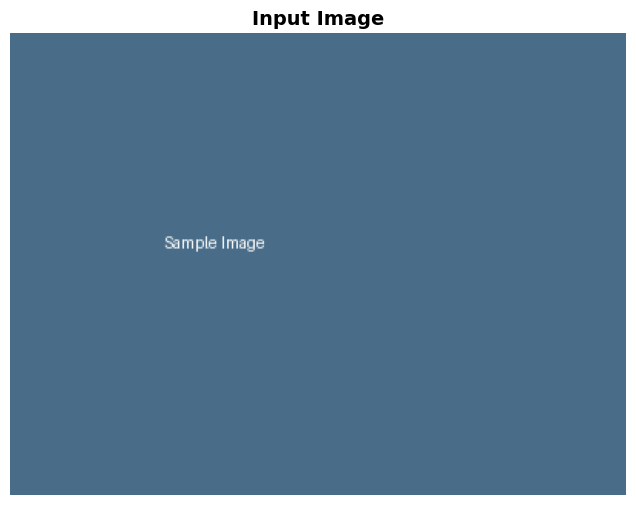


Semantic Vector:
  Shape: torch.Size([1, 1024])
  Norm: 1.4678

Generated Text:
  In the meantime, though, there is still plenty of room for improvement, especially in the form of improved lighting. For example, the lighting has improved dramatically over the past few weeks. This is especially true for those who live in the


In [7]:
def cross_modal_inference(image: Image.Image, encoder, decoder, device: str = DEVICE):
    """
    Perform full cross-modal inference: Image → Semantic Vector → Text.
    
    Args:
        image: PIL Image
        encoder: Image_to_Vec instance
        decoder: Vec_to_Text instance
        device: Device to run inference on
    
    Returns:
        (semantic_vector, generated_text)
    """
    with torch.no_grad():
        # Step 1: Image → Semantic Vector
        semantic_vector = encoder(image, device=device)
        
        # Step 2: Semantic Vector → Text
        generated_text = decoder(semantic_vector, device=device)
    
    return semantic_vector, generated_text

# Run inference
semantic_vec, text_output = cross_modal_inference(image, image_encoder, text_decoder)

# Display results
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(image)
ax.axis('off')
ax.set_title("Input Image", fontsize=14, fontweight='bold')
plt.show()

print("\nSemantic Vector:")
print(f"  Shape: {semantic_vec.shape}")
print(f"  Norm: {torch.norm(semantic_vec).item():.4f}")
print(f"\nGenerated Text:")
print(f"  {text_output}")

## Key Insights

### 1. **Shared Semantic Space**
The 1024-dimensional vector represents the **meaning** of the image in a modality-agnostic way. Any modality (text, audio, video) aligned to this space can be compared using simple cosine similarity.

### 2. **No Direct Translation**
We never trained an "Image→Text" model directly. Instead:
- Image encoder was trained to align with the semantic space (using contrastive learning)
- Text decoder was trained to generate from the semantic space (using backtranslation)
- The cross-modal inference emerges from the shared representation

### 3. **100x Training Efficiency**
Only the small MLP adapters were trained (~2M parameters each). The large pretrained models (ViT-GPT2, BART) remained frozen, making training 100x cheaper than full fine-tuning.

### 4. **Extensibility**
Adding new modalities (audio, video, depth, etc.) only requires:
1. Training a new encoder adapter to the semantic space
2. All existing decoders immediately work with the new modality

### 5. **Cross-Modal Understanding**
Since all modalities share the same semantic space, we can:
- Compare images to text using cosine similarity
- Search across modalities ("find images similar to this audio")
- Perform inference in the vector space directly

## Next Steps

Try these experiments:

1. **Load your own images**: Replace the sample image with real photos and observe the generated descriptions

2. **Compare semantic vectors**: Encode multiple images and compute cosine similarity between their vectors to find similar images

3. **Text-to-Image search**: Encode text queries using `Text_to_Vec` and compare to image vectors

4. **Audio-to-Text**: Use `Audio_to_Vec` + `Vec_to_Text` to transcribe and describe audio

5. **Round-trip translation**: Encode an image, decode to text, re-encode the text, and measure semantic drift

## Additional Example: Semantic Similarity

Let's demonstrate how to compare multiple images in the semantic space.

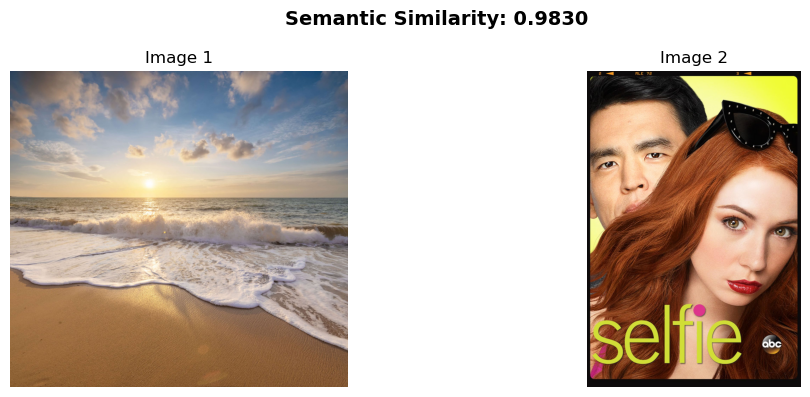


Cosine Similarity in Semantic Space: 0.9830

Note: Higher similarity (closer to 1.0) means the images have similar semantic content.


In [9]:
def cosine_similarity(vec1: torch.Tensor, vec2: torch.Tensor) -> float:
    """Compute cosine similarity between two vectors."""
    return torch.nn.functional.cosine_similarity(vec1, vec2, dim=-1).item()

# Create two sample images
# image1 = Image.new('RGB', (400, 300), color=(100, 150, 200))
# draw1 = ImageDraw.Draw(image1)
# draw1.text((120, 130), "Blue Image", fill=(255, 255, 255))
image1 = Image.open('./data/validation/beach_1.jpg')

# image2 = Image.new('RGB', (400, 300), color=(200, 100, 100))
# draw2 = ImageDraw.Draw(image2)
# draw2.text((120, 130), "Red Image", fill=(255, 255, 255))
image2 = Image.open('./data/validation/selfie_1.jpg')



# Encode both images
with torch.no_grad():
    vec1 = image_encoder(image1, device=DEVICE)
    vec2 = image_encoder(image2, device=DEVICE)

# Compute similarity
similarity = cosine_similarity(vec1, vec2)

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(image1)
axes[0].axis('off')
axes[0].set_title('Image 1')

axes[1].imshow(image2)
axes[1].axis('off')
axes[1].set_title('Image 2')

plt.suptitle(f'Semantic Similarity: {similarity:.4f}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nCosine Similarity in Semantic Space: {similarity:.4f}")
print("\nNote: Higher similarity (closer to 1.0) means the images have similar semantic content.")